# Plots Paper

In this notebook, we produce the plots of the paper

In [80]:
import os
import matplotlib.pyplot as plt
import h5py
import numpy as np
import healpy as hp
from matplotlib.colors import LogNorm

results_dir = 'segwo_results/static_boost1.0/'
results_dir = 'segwo_results/15.0days_evolving_boost1.0/'
# results_dir = 'segwo_results/15.0days_evolving_boost0.0/'

output_dir = results_dir.rstrip('/') + '/'
hdf5_path  = os.path.join(output_dir, "results.h5")
output_dir, hdf5_path

pols=(r'$h_+$', r'$h_\times$')

In [81]:
print(f"Loading results from {hdf5_path} …")
with h5py.File(hdf5_path, "r") as hf:
    f         = hf["metadata/frequencies"][()]
    betas     = hf["metadata/betas"][()]
    lambs     = hf["metadata/lambs"][()]
    nside     = int(hf["metadata"].attrs["nside"])
    npix      = int(hf["metadata"].attrs["npix"])
    run_flag  = str(hf["metadata"].attrs["run_flag"])

    strain2x_nominal = (hf["nominal/strain2x_real"][()] +
                        1j * hf["nominal/strain2x_imag"][()])

    ltt_residuals      = hf["perturbed/ltt_residuals"][()]
    position_residuals = hf["perturbed/position_residuals"][()]

    strain2x_abs_error   = hf["errors/strain2x_abs_error"][()]
    strain2x_angle_error = hf["errors/strain2x_angle_error"][()]
    mismatch             = hf["errors/mismatch"][()]
    amp_violation_ratio   = float(hf["errors"].attrs["amp_violation_ratio"])
    phase_violation_ratio = float(hf["errors"].attrs["phase_violation_ratio"])

print(f"  run_flag                 : {run_flag}")


Loading results from segwo_results/15.0days_evolving_boost1.0/results.h5 …
  run_flag                 : evolving


# Mismatch Analysis

In [82]:
nan_mask = np.isnan(mismatch)
print(f"  Number of NaN values in {pols[0]}: {nan_mask.sum(axis=(0,1,2))[0]} out of {mismatch.size}")
print(f"  Number of NaN values in {pols[1]}: {nan_mask.sum(axis=(0,1,2))[1]} out of {mismatch.size}")
metric_func = np.max

  Number of NaN values in $h_+$: 0 out of 129600000
  Number of NaN values in $h_\times$: 0 out of 129600000


<Figure size 640x480 with 0 Axes>

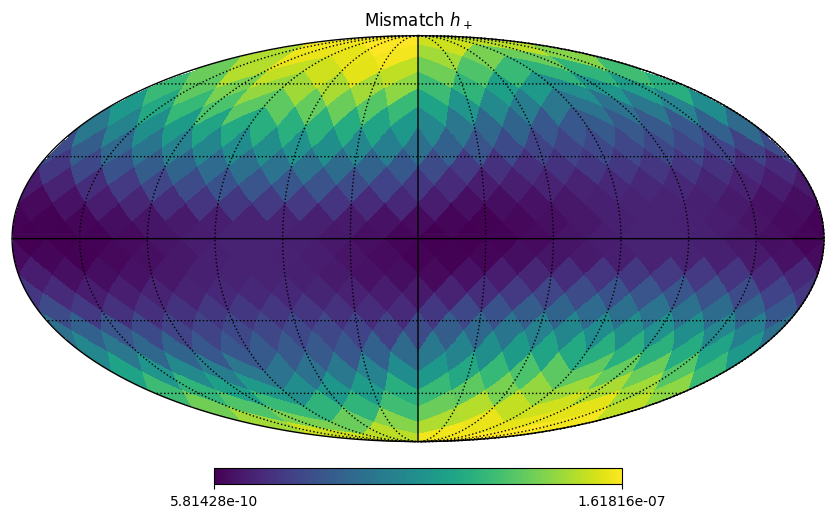

<Figure size 640x480 with 0 Axes>

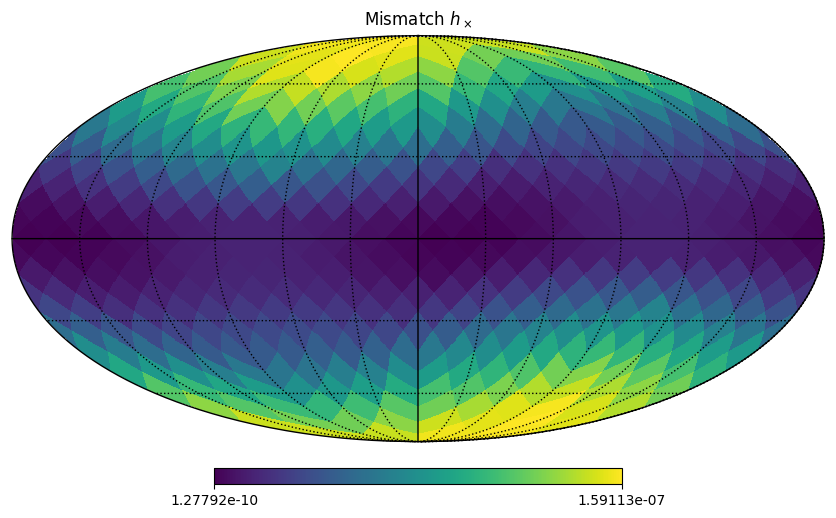

In [83]:
# mismatch over sky max across frequencies and realizations
response_map = metric_func(mismatch,axis=(0,1))
for pol in range(2):
    plt.figure()
    hp.mollview(response_map[...,pol],title=f"Mismatch {pols[pol]}",rot=[0, 0])
    hp.graticule()
    

(150, 2)


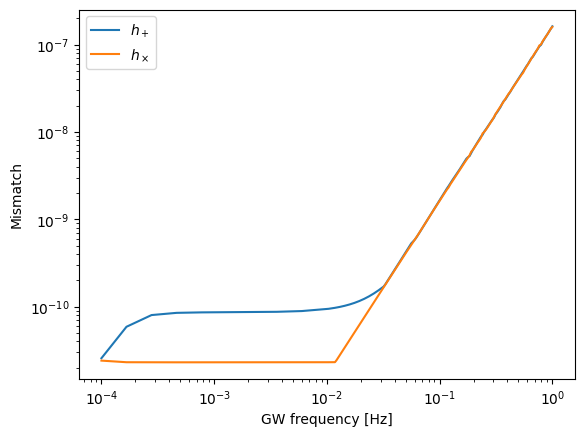

In [84]:
mismatch[nan_mask] = 0.0
frequency_map = metric_func(mismatch,axis=(0,2))
print(frequency_map.shape)
plt.figure()
for j in range(2):
    plt.loglog(f, frequency_map[...,j], label=f'{pols[j]}')
plt.legend()
plt.xlabel("GW frequency [Hz]")
plt.ylabel("Mismatch")
plt.legend()

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_35069/1644415125.py:15: SyntaxWarning: invalid escape sequence '\m'
  cbar.set_label("Mismatch $\mathcal{M}$")


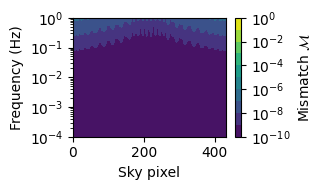

In [85]:
pol = 0
z = metric_func(mismatch,axis=(0))[..., pol]
vmin = 1e-10 #np.max([1e-10,z.min()])
vmax = 1.0 #np.min([1.0,z.max()])
z[z<vmin] = vmin
z[z>vmax] = vmax

dmin = np.floor(np.log10(vmin)) # down to lower decade
dmax = np.ceil(np.log10(vmax)) # up to upper decade
levels = np.logspace(dmin, dmax, num=int(dmax - dmin + 1))
plt.figure(figsize=(3.25, 2))
cf = plt.contourf(np.arange(z.shape[1]), f, z, levels=levels, norm=LogNorm(vmin=vmin, vmax=vmax),cmap="viridis")
plt.yscale("log")  # same as semilogy for axis scaling
cbar = plt.colorbar(cf)
cbar.set_label("Mismatch $\mathcal{M}$")
plt.xlabel("Sky pixel")
plt.ylabel("Frequency (Hz)")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "mismatch_contour.png"), dpi=300)
plt.show()

## Multi-Case Analysis

This section loads and compares three result cases:
- `static_boost1.0`
- `15.0days_evolving_boost1.0`
- `15.0days_evolving_boost0.0`

Each case is analyzed separately, then compared as a function of GW frequency.

In [102]:
case_dirs = {
    "static_boost1.0": "segwo_results/static_boost1.0/",
    "15.0days_evolving_boost1.0": "segwo_results/15.0days_evolving_boost1.0/",
    "15.0days_evolving_boost0.0": "segwo_results/15.0days_evolving_boost0.0/",
    # "0.0days_evolving_boost1.0": "segwo_results/0.0days_evolving_boost1.0/",
    # "0.0days_evolving_boost0.0": "segwo_results/0.0days_evolving_boost0.0/",
}


def load_case_results(results_dir):
    hdf5_path = os.path.join(results_dir, "results.h5")
    if not os.path.exists(hdf5_path):
        raise FileNotFoundError(f"Missing file: {hdf5_path}")

    with h5py.File(hdf5_path, "r") as hf:
        data = {
            "frequencies": hf["metadata/frequencies"][()],
            "betas": hf["metadata/betas"][()],
            "lambs": hf["metadata/lambs"][()],
            "nside": int(hf["metadata"].attrs["nside"]),
            "npix": int(hf["metadata"].attrs["npix"]),
            "run_flag": str(hf["metadata"].attrs["run_flag"]),
            "mismatch": hf["errors/mismatch"][()],
            "strain2x_abs_error": hf["errors/strain2x_abs_error"][()],
            "strain2x_angle_error": hf["errors/strain2x_angle_error"][()],
            "amp_violation_ratio": float(hf["errors"].attrs["amp_violation_ratio"]),
            "phase_violation_ratio": float(hf["errors"].attrs["phase_violation_ratio"]),
            "mismatch_boost": hf["nominal/mismatch_boost"][()],
        }

    data["mismatch_clean"] = np.nan_to_num(data["mismatch"], nan=0.0, posinf=0.0, neginf=0.0)
    return data


all_cases = {}
for case_name, case_dir in case_dirs.items():
    all_cases[case_name] = load_case_results(case_dir)
    d = all_cases[case_name]
    print(
        f"Loaded {case_name}: "
        f"Nf={d['frequencies'].size}, Npix={d['npix']}, run_flag={d['run_flag']}, "
        f"amp_violation={d['amp_violation_ratio']:.3e}, "
        f"phase_violation={d['phase_violation_ratio']:.3e}"
    )

reference_case = next(iter(all_cases.values()))
frequencies = reference_case["frequencies"]
pols = (r"$h_+$", r"$h_\times$")

for case_name, d in all_cases.items():
    if not np.allclose(d["frequencies"], frequencies):
        raise ValueError(f"Frequency grid mismatch for case {case_name}")


def summarize_frequency_curves(arr):
    # Robustly identify the frequency axis, then aggregate all other non-pol axes.
    n_freq = frequencies.size
    if arr.ndim < 2:
        raise ValueError(f"Expected at least 2 dimensions, got shape {arr.shape}")

    freq_axes = [ax for ax, size in enumerate(arr.shape[:-1]) if size == n_freq]
    if not freq_axes:
        raise ValueError(
            f"Could not find frequency axis of size {n_freq} in array shape {arr.shape}"
        )

    # Prefer axis 1 when available (common layout: realization, frequency, sky, pol).
    freq_axis = 1 if (arr.ndim > 1 and arr.shape[1] == n_freq) else freq_axes[0]

    arr_freq_first = np.moveaxis(arr, freq_axis, 0)
    arr_flat = arr_freq_first.reshape(n_freq, -1, arr.shape[-1])
    return {
        "min": arr_flat.min(axis=1),
        "mean": arr_flat.mean(axis=1),
        "max": arr_flat.max(axis=1),
    }

Loaded static_boost1.0: Nf=150, Npix=432, run_flag=static, amp_violation=4.237e-01, phase_violation=2.627e-02
Loaded 15.0days_evolving_boost1.0: Nf=150, Npix=432, run_flag=evolving, amp_violation=1.296e-03, phase_violation=0.000e+00
Loaded 15.0days_evolving_boost0.0: Nf=150, Npix=432, run_flag=evolving, amp_violation=3.962e-01, phase_violation=1.368e-03


## Case 1: static_boost1.0

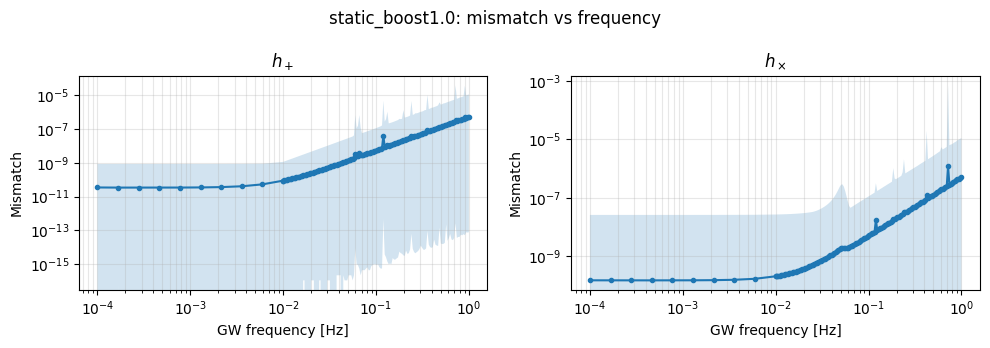

In [103]:
case_name = "static_boost1.0"
d = all_cases[case_name]

mismatch_stats = summarize_frequency_curves(d["mismatch_clean"])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharex=True)
for j in range(2):
    axes[j].fill_between(
        frequencies,
        mismatch_stats["min"][:, j],
        mismatch_stats["max"][:, j],
        alpha=0.2,
    )
    axes[j].plot(frequencies, mismatch_stats["mean"][:, j], "-o", ms=3)
    axes[j].set_xscale("log")
    axes[j].set_yscale("log")
    axes[j].set_xlabel("GW frequency [Hz]")
    axes[j].set_ylabel("Mismatch")
    axes[j].set_title(pols[j])
    axes[j].grid(True, which="both", alpha=0.3)

fig.suptitle(f"{case_name}: mismatch vs frequency")
plt.tight_layout()
plt.show()

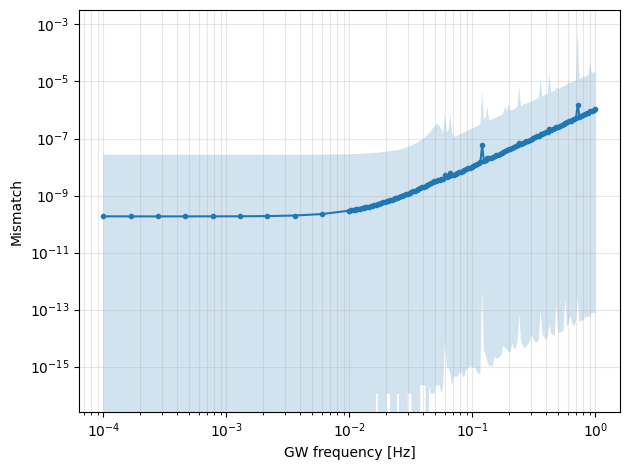

In [104]:
case_name = "static_boost1.0"
d = all_cases[case_name]

mismatch_stats = summarize_frequency_curves(d["mismatch_clean"])

plt.fill_between(
    frequencies,
    mismatch_stats["min"][:, :].sum(axis=1),
    mismatch_stats["max"][:, :].sum(axis=1),
    alpha=0.2,
)
plt.loglog(frequencies, mismatch_stats["mean"][:, :].sum(axis=1), "-o", ms=3)
plt.xlabel("GW frequency [Hz]")
plt.ylabel("Mismatch")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## Case 2: 15.0days_evolving_boost1.0

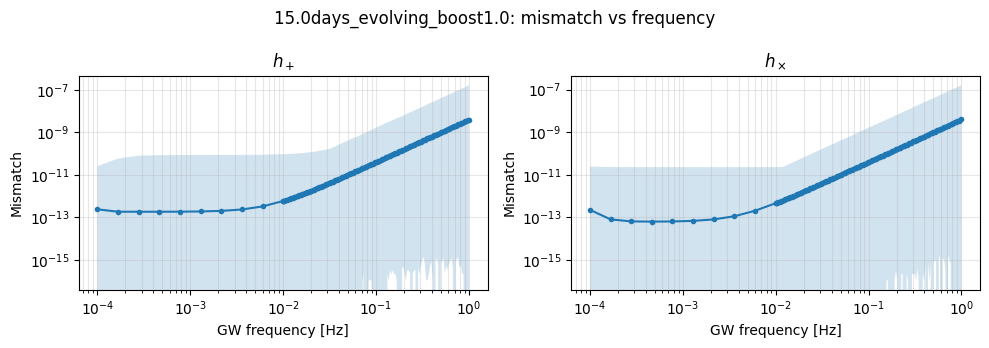

In [105]:
case_name = "15.0days_evolving_boost1.0"
d = all_cases[case_name]

mismatch_stats = summarize_frequency_curves(d["mismatch_clean"])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharex=True)
for j in range(2):
    axes[j].fill_between(
        frequencies,
        mismatch_stats["min"][:, j],
        mismatch_stats["max"][:, j],
        alpha=0.2,
    )
    axes[j].plot(frequencies, mismatch_stats["mean"][:, j], "-o", ms=3)
    axes[j].set_xscale("log")
    axes[j].set_yscale("log")
    axes[j].set_xlabel("GW frequency [Hz]")
    axes[j].set_ylabel("Mismatch")
    axes[j].set_title(pols[j])
    axes[j].grid(True, which="both", alpha=0.3)

fig.suptitle(f"{case_name}: mismatch vs frequency")
plt.tight_layout()
plt.show()

## Case 3: 15.0days_evolving_boost0.0

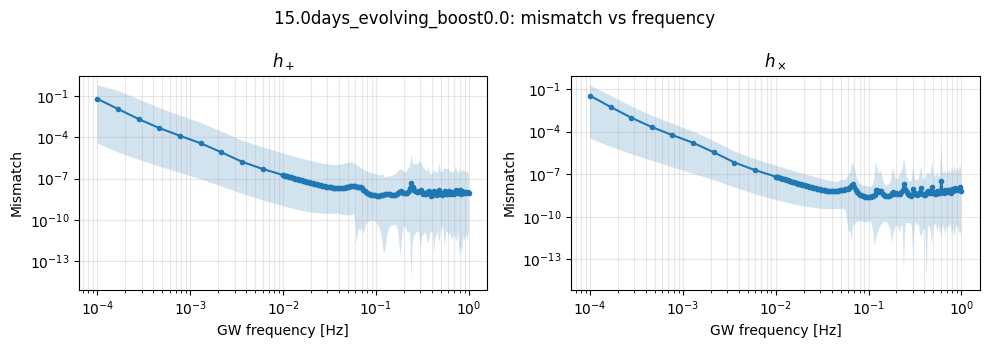

In [107]:
case_name = "15.0days_evolving_boost0.0"
d = all_cases[case_name]

mismatch_stats = summarize_frequency_curves(d["mismatch_clean"])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharex=True)
for j in range(2):
    axes[j].fill_between(
        frequencies,
        mismatch_stats["min"][:, j],
        mismatch_stats["max"][:, j],
        alpha=0.2,
    )
    axes[j].plot(frequencies, mismatch_stats["mean"][:, j], "-o", ms=3)
    axes[j].set_xscale("log")
    axes[j].set_yscale("log")
    axes[j].set_xlabel("GW frequency [Hz]")
    axes[j].set_ylabel("Mismatch")
    axes[j].set_title(pols[j])
    axes[j].grid(True, which="both", alpha=0.3)

fig.suptitle(f"{case_name}: mismatch vs frequency")
plt.tight_layout()
plt.show()

## Cross-Case Comparison vs Frequency

The plots below compare the three cases directly as a function of GW frequency.
Shaded regions show min-max over realizations and sky pixels, and the `-o` curves show the mean.

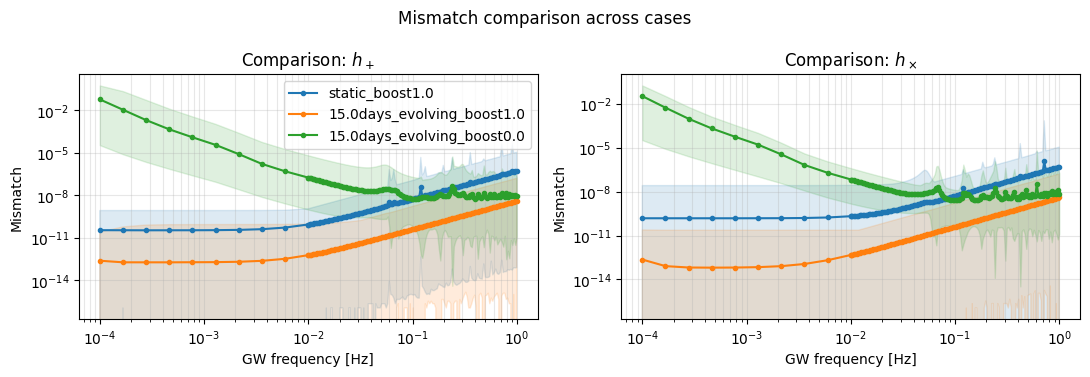

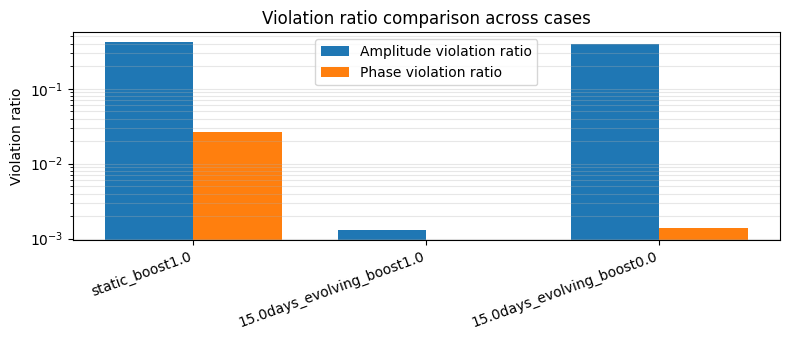

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharex=True)
colors = {
    "static_boost1.0": "tab:blue",
    "15.0days_evolving_boost1.0": "tab:orange",
    "15.0days_evolving_boost0.0": "tab:green",
}

for case_name, d in all_cases.items():
    mismatch_stats = summarize_frequency_curves(d["mismatch_clean"])
    for j in range(2):
        axes[j].fill_between(
            frequencies,
            mismatch_stats["min"][:, j],
            mismatch_stats["max"][:, j],
            color=colors[case_name],
            alpha=0.15,
        )
        axes[j].plot(
            frequencies,
            mismatch_stats["mean"][:, j],
            "-o",
            ms=3,
            color=colors[case_name],
            label=case_name if j == 0 else None,
        )

for j in range(2):
    axes[j].set_xscale("log")
    axes[j].set_yscale("log")
    axes[j].set_xlabel("GW frequency [Hz]")
    axes[j].set_ylabel("Mismatch")
    axes[j].set_title(f"Comparison: {pols[j]}")
    axes[j].grid(True, which="both", alpha=0.3)

axes[0].legend(loc="best")
fig.suptitle("Mismatch comparison across cases")
plt.tight_layout()
plt.show()


# Compare violation ratios for each case
case_names = list(all_cases.keys())
amp_vals = [all_cases[name]["amp_violation_ratio"] for name in case_names]
phase_vals = [all_cases[name]["phase_violation_ratio"] for name in case_names]

x = np.arange(len(case_names))
width = 0.38

plt.figure(figsize=(8, 3.5))
plt.bar(x - width / 2, amp_vals, width=width, label="Amplitude violation ratio")
plt.bar(x + width / 2, phase_vals, width=width, label="Phase violation ratio")
plt.yscale("log")
plt.xticks(x, case_names, rotation=20, ha="right")
plt.ylabel("Violation ratio")
plt.title("Violation ratio comparison across cases")
plt.grid(True, axis="y", which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()